In [38]:
# Cell 1 — Imports & Config
import h5py
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from collections import defaultdict
from sklearn.preprocessing import normalize

H5_PATH       = "../embeddings/cct_dinov2l_embeddings_v2.h5"
IMAGE_BASE    = "/media/Data-10T-1/Bhavesh-project/cct_data"
N_BLOCKS      = 10
K_FACTOR      = 0.5
INIT_TRAIN_RATIO = 1

print("Config ready.")

Config ready.


In [39]:
# Cell 2 — Load HDF5 & Apply Mask
with h5py.File(H5_PATH, "r") as hf:
    raw_embeddings   = hf["embeddings"][:]
    raw_species      = np.array([s.decode() for s in hf["species"][:]])
    raw_strings      = [t.decode() for t in hf["date_captured"][:]]
    raw_locations    = np.array([l.decode() for l in hf["location"][:]])
    raw_file_names   = np.array([f.decode() for f in hf["file_name"][:]])

temp_times = pd.to_datetime(raw_strings, errors="coerce")
mask = temp_times.notna()

embeddings = normalize(raw_embeddings[mask], norm="l2")
species    = raw_species[mask]
timestamps = temp_times[mask]
locations  = raw_locations[mask]
file_names = raw_file_names[mask]      # <-- masked file names
dates_arr  = timestamps.normalize()   # date-only, for block partitioning

print(f"Loaded {len(embeddings):,} embeddings after masking.")
print(f"Dropped {len(mask) - mask.sum()} rows with invalid timestamps.")

Loaded 107,149 embeddings after masking.
Dropped 1 rows with invalid timestamps.


In [40]:
# Cell 3 — Build Temporal Blocks
def make_date_aware_blocks(dates_arr, n_blocks):
    N = len(dates_arr)
    target_block_size = N / n_blocks
    date_to_indices = defaultdict(list)
    for idx, d in enumerate(dates_arr):
        date_to_indices[d].append(idx)
    unique_dates = sorted(date_to_indices.keys())
    blocks    = [[] for _ in range(n_blocks)]
    cur_block = 0
    cumulative = 0
    for d in unique_dates:
        idxs = date_to_indices[d]
        blocks[cur_block].extend(idxs)
        cumulative += len(idxs)
        if cur_block < n_blocks - 1 and cumulative >= (cur_block + 1) * target_block_size:
            cur_block += 1
    return [np.array(b) for b in blocks if len(b) > 0]

blocks = make_date_aware_blocks(dates_arr, N_BLOCKS)
print(f"Created {len(blocks)} temporal blocks.")
print(f"{'Block':>6}  {'Size':>7}  {'Date range'}")
print("-" * 55)
for i, b in enumerate(blocks):
    d_min = dates_arr[b].min()
    d_max = dates_arr[b].max()
    print(f"  {i+1:>4}  {len(b):>7,}  {d_min}  →  {d_max}")

Created 10 temporal blocks.
 Block     Size  Date range
-------------------------------------------------------
     1   10,798  2010-05-25 00:00:00  →  2011-06-14 00:00:00
     2   10,685  2011-06-15 00:00:00  →  2011-09-14 00:00:00
     3   10,767  2011-09-15 00:00:00  →  2012-01-03 00:00:00
     4   10,659  2012-01-04 00:00:00  →  2012-03-28 00:00:00
     5   10,710  2012-03-29 00:00:00  →  2012-05-25 00:00:00
     6   10,755  2012-05-26 00:00:00  →  2013-10-23 00:00:00
     7   10,734  2013-10-24 00:00:00  →  2014-01-24 00:00:00
     8   10,769  2014-01-25 00:00:00  →  2014-05-07 00:00:00
     9   10,571  2014-05-08 00:00:00  →  2014-09-07 00:00:00
    10   10,701  2014-09-08 00:00:00  →  2015-06-03 00:00:00


In [41]:
# Cell 4 — Classifier Definition
class AdaptiveNCMClassifier:
    def __init__(self, k_factor=0.5):
        self.k_factor = k_factor
        self.prototypes = {}
        self.counts     = {}
        self.mean_dists = {}
        self.m2_dists   = {}

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _dist_to_proto(self, emb, cls):
        proto_norm = self._normalized(self.prototypes[cls])
        emb_norm   = self._normalized(emb)
        dot = np.clip(np.dot(proto_norm, emb_norm), -1.0, 1.0)
        return np.sqrt(max(0.0, 2.0 - 2.0 * dot))

    def _get_radius(self, cls):
        n = self.counts[cls]
        if n < 2:
            return 0.15
        variance = max(0.0, self.m2_dists[cls] / (n - 1))
        std = np.sqrt(variance)
        return self.mean_dists[cls] + self.k_factor * std

    def fit(self, g_embs, g_labels):
        for cls in np.unique(g_labels):
            cls_embs = g_embs[g_labels == cls]
            n = len(cls_embs)
            self.counts[cls] = n
            proto = np.mean(cls_embs, axis=0)
            self.prototypes[cls] = proto
            proto_norm = self._normalized(proto)
            dots  = np.clip(cls_embs.dot(proto_norm), -1.0, 1.0)
            dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
            self.mean_dists[cls] = np.mean(dists)
            self.m2_dists[cls]   = np.sum((dists - self.mean_dists[cls]) ** 2)

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)
        if n == 0:
            self.prototypes[species] = new_emb.copy()
            self.counts[species]     = 1
            self.mean_dists[species] = 0.0
            self.m2_dists[species]   = 0.0
            return
        old_proto = self.prototypes[species]
        new_n = n + 1
        old_proto_norm = self._normalized(old_proto)
        new_emb_norm   = self._normalized(new_emb)
        dot = np.clip(np.dot(old_proto_norm, new_emb_norm), -1.0, 1.0)
        new_dist = np.sqrt(max(0.0, 2.0 - 2.0 * dot))
        delta    = new_dist - self.mean_dists[species]
        new_mean = self.mean_dists[species] + delta / new_n
        delta2   = new_dist - new_mean
        self.mean_dists[species]  = new_mean
        self.m2_dists[species]   += delta * delta2
        self.prototypes[species]  = (old_proto * n + new_emb) / new_n
        self.counts[species]      = new_n

    def predict(self, query_emb):
        species_list = list(self.prototypes.keys())
        query_norm   = self._normalized(query_emb)
        protos_norm  = np.array([self._normalized(self.prototypes[cls]) for cls in species_list])
        dots  = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
        within_radius = [
            i for i, (cls, dist) in enumerate(zip(species_list, dists))
            if dist <= self._get_radius(cls)
        ]
        if not within_radius:
            nearest_idx = np.argmin(dists)
            return species_list[nearest_idx], True
        best_idx = min(within_radius, key=lambda i: dists[i])
        return species_list[best_idx], False

    @property
    def known_species(self):
        return set(self.prototypes.keys())

print("Classifier defined.")

Classifier defined.


In [42]:
# Cell 5 — Fit Both Classifiers on Block 1
blk1_idx = blocks[0]
np.random.seed(42)
shuffled = np.random.permutation(blk1_idx)
split    = int(len(shuffled) * INIT_TRAIN_RATIO)
train_idx, val_idx = shuffled[:split], shuffled[split:]

train_embs = embeddings[train_idx]
train_lbls = species[train_idx]

static_clf   = AdaptiveNCMClassifier(k_factor=K_FACTOR)
adaptive_clf = AdaptiveNCMClassifier(k_factor=K_FACTOR)

static_clf.fit(train_embs, train_lbls)
adaptive_clf.fit(train_embs, train_lbls)

# Update adaptive on Block 1 validation set so it has seen all of block 1
#for emb, lbl in zip(embeddings[val_idx], species[val_idx]):
#    adaptive_clf.update(emb, lbl)

fixed_eval_species = static_clf.known_species.copy()  # Block-1 species snapshot

print(f"Fitted on {len(train_idx):,} Block-1 training samples.")
print(f"Known species after Block 1: {len(fixed_eval_species)}")

Fitted on 10,798 Block-1 training samples.
Known species after Block 1: 15


In [43]:
# Cell 6 — Per-Sample Comparison Loop (Blocks 2–10)
#
# For every sample in blocks 2–10 whose true label is in fixed_eval_species,
# record both classifiers' predictions and whether each was correct.
# After evaluating each block, update ONLY the adaptive classifier.

records = []  # list of dicts, one per sample

for blk_num, blk_idx in enumerate(blocks[1:], start=2):
    blk_idx  = np.asarray(blk_idx)
    blk_embs = embeddings[blk_idx]
    blk_lbls = species[blk_idx]
    blk_fns  = file_names[blk_idx]

    for emb, lbl, fn in zip(blk_embs, blk_lbls, blk_fns):
        # Only analyse samples whose true label is in the fixed evaluation set
        if lbl not in fixed_eval_species:
            continue

        s_pred, s_unk = static_clf.predict(emb)
        a_pred, a_unk = adaptive_clf.predict(emb)

        # "Correct" means: not flagged unknown AND predicted label matches true label
        #static_correct   = (not s_unk) and (s_pred == lbl)
        #adaptive_correct = (not a_unk) and (a_pred == lbl)
        
        static_correct = (s_pred==lbl)
        adaptive_correct = (a_pred==lbl)

        records.append({
            "file_name"        : fn,
            "true_label"       : lbl,
            "block"            : blk_num,
            "static_pred"      : s_pred,
            "static_is_unknown": s_unk,
            "static_correct"   : static_correct,
            "adaptive_pred"    : a_pred,
            "adaptive_is_unknown": a_unk,
            "adaptive_correct" : adaptive_correct,
        })

    # Update ONLY the adaptive classifier after evaluating each block
    for emb, lbl in zip(blk_embs, blk_lbls):
        adaptive_clf.update(emb, lbl)

    print(f"Block {blk_num}: {len(blk_idx):,} samples processed.")

all_df = pd.DataFrame(records)
print(f"\nTotal samples recorded: {len(all_df):,}")

Block 2: 10,685 samples processed.
Block 3: 10,767 samples processed.
Block 4: 10,659 samples processed.
Block 5: 10,710 samples processed.
Block 6: 10,755 samples processed.
Block 7: 10,734 samples processed.
Block 8: 10,769 samples processed.
Block 9: 10,571 samples processed.
Block 10: 10,701 samples processed.

Total samples recorded: 92,304


In [44]:
# Cell 7 — Filter: Static Wrong, Adaptive Correct
mismatch_df = all_df[
    (~all_df["static_correct"]) & (all_df["adaptive_correct"])
].reset_index(drop=True)

print(f"Samples where static is WRONG and adaptive is CORRECT: {len(mismatch_df):,}")
print(f"Breakdown by block:")
print(mismatch_df.groupby("block").size().rename("count").to_string())
print(f"\nBreakdown by true species:")
print(mismatch_df.groupby("true_label").size().sort_values(ascending=False).rename("count").to_string())

Samples where static is WRONG and adaptive is CORRECT: 6,323
Breakdown by block:
block
3      337
4      363
5      399
6      609
7      773
8     1418
9     1058
10    1366

Breakdown by true species:
true_label
bird        4038
fox          606
raccoon      555
cat          288
dog          283
opossum      179
deer         104
rodent        97
coyote        96
skunk         29
rabbit        20
car           14
bobcat        13
squirrel       1


In [45]:
# Cell 8 — Save Mismatch DataFrame
mismatch_df.to_csv("mismatch_static_wrong_adaptive_correct.csv", index=False)

print("Saved mismatch_static_wrong_adaptive_correct.csv")

mismatch_df.head(5)

Saved mismatch_static_wrong_adaptive_correct.csv


,file_name,true_label,block,static_pred,static_is_unknown,static_correct,adaptive_pred,adaptive_is_unknown,adaptive_correct
0,588f6742-23d2-11e8-a6a3-ec086b02610b.jpg,raccoon,3,cat,False,False,raccoon,False,True
1,58f73cd0-23d2-11e8-a6a3-ec086b02610b.jpg,raccoon,3,rodent,False,False,raccoon,False,True
2,587b7faa-23d2-11e8-a6a3-ec086b02610b.jpg,raccoon,3,rodent,False,False,raccoon,False,True
3,59328c3d-23d2-11e8-a6a3-ec086b02610b.jpg,raccoon,3,rodent,False,False,raccoon,False,True
4,59292e2d-23d2-11e8-a6a3-ec086b02610b.jpg,bird,3,bobcat,True,False,bird,True,True


In [46]:
# Cell 9 — Build Species Index
# species_index[species_name] → list of row dicts (file_name, block, predictions, …)

species_index = defaultdict(list)
for _, row in mismatch_df.iterrows():
    species_index[row["true_label"]].append(row.to_dict())

print(f"Species with misclassified-by-static samples: {len(species_index)}")
for sp, rows in sorted(species_index.items(), key=lambda x: -len(x[1])):
    print(f"  {sp:<30} {len(rows):>5} samples")

Species with misclassified-by-static samples: 14
  bird                            4038 samples
  fox                              606 samples
  raccoon                          555 samples
  cat                              288 samples
  dog                              283 samples
  opossum                          179 samples
  deer                             104 samples
  rodent                            97 samples
  coyote                            96 samples
  skunk                             29 samples
  rabbit                            20 samples
  car                               14 samples
  bobcat                            13 samples
  squirrel                           1 samples


In [52]:
# Cell 10 — Load MD lookup & Scrollable Visualization (no paging, show filenames, cap at 100)

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, clear_output
import ipywidgets as widgets

MD_JSON_PATH = "json_files/cct_md.json"

def dataset_path_to_local_name(path_like: str) -> str:
    normalized = str(path_like).replace("\\", "/")
    from pathlib import PurePosixPath
    return str(PurePosixPath(normalized)).replace("/", "_")

print("Loading MegaDetector JSON...")
with open(MD_JSON_PATH) as f:
    md_data = json.load(f)

md_lookup = {}
for image in md_data["images"]:
    animal_dets = [d for d in image.get("detections", []) if str(d.get("category")) == "1"]
    if not animal_dets:
        continue
    best_det = max(animal_dets, key=lambda d: float(d["conf"]))
    local_name = dataset_path_to_local_name(image["file"])
    md_lookup[local_name] = best_det

print(f"MD lookup built: {len(md_lookup):,} entries.")


def draw_bbox_on_ax(ax, image, bbox):
    img_w, img_h = image.size
    x_min = bbox[0] * img_w
    y_min = bbox[1] * img_h
    box_w = bbox[2] * img_w
    box_h = bbox[3] * img_h
    rect = patches.Rectangle(
        (x_min, y_min), box_w, box_h,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rect)


def show_misclassified(species_name: str, ncols: int = 4, img_size: float = 5.0,
                       max_images: int = 100):
    """
    Scrollable visualization with no pagination.
    Shows up to max_images for a species in one vertically scrollable output area.

    Parameters
    ----------
    species_name : species to inspect
    ncols        : number of columns in the grid
    img_size     : size of each image cell in inches
    max_images   : maximum number of images to display
    """
    if species_name not in species_index:
        print(f"Species '{species_name}' not found.")
        print(f"Available: {sorted(species_index.keys())}")
        return

    all_rows = species_index[species_name]
    total_available = len(all_rows)
    rows = all_rows[:max_images]
    total_shown = len(rows)
    nrows = (total_shown + ncols - 1) // ncols

    out = widgets.Output(layout=widgets.Layout(
        overflow_y="scroll",
        height="700px",
        width="100%",
        border="1px solid #ccc"
    ))

    with out:
        clear_output(wait=True)

        plt.rcParams["figure.dpi"] = 120
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(ncols * img_size, nrows * img_size)
        )
        axes = np.array(axes).reshape(-1)

        fig.suptitle(
            f"Species: {species_name}  |  Showing {total_shown} of {total_available} samples  |  "
            f"[Static WRONG, Adaptive CORRECT]",
            fontsize=12,
            fontweight="bold"
        )

        for ax, row in zip(axes[:total_shown], rows):
            img_path = Path(IMAGE_BASE) / row["file_name"]
            local_name = dataset_path_to_local_name(row["file_name"])
            det = md_lookup.get(local_name)

            try:
                image = Image.open(img_path).convert("RGB")
                ax.imshow(image)

                if det is not None:
                    draw_bbox_on_ax(ax, image, det["bbox"])
                else:
                    ax.text(
                        0.5, 0.02, "No bbox",
                        ha="center", transform=ax.transAxes,
                        fontsize=7, color="orange"
                    )
            except Exception as e:
                ax.set_facecolor("#eee")
                ax.text(
                    0.5, 0.5, f"Load error\n{e}",
                    ha="center", va="center",
                    transform=ax.transAxes, fontsize=7, color="red"
                )

            s_label = row["static_pred"] + (" (unk)" if row["static_is_unknown"] else "")
            caption = (
                f"File: {row['file_name']}\n"
                f"True: {row['true_label']}  |  Block: {row['block']}\n"
                f"Static: {s_label}  |  Adaptive: {row['adaptive_pred']}"
            )
            ax.set_title(caption, fontsize=8, pad=4)
            ax.axis("off")

        for ax in axes[total_shown:]:
            ax.axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    display(out)

Loading MegaDetector JSON...
MD lookup built: 169,352 entries.


In [ ]:
# Cell 11 — Run Visualization (edit species name and page as needed)
show_misclassified("bobcat")

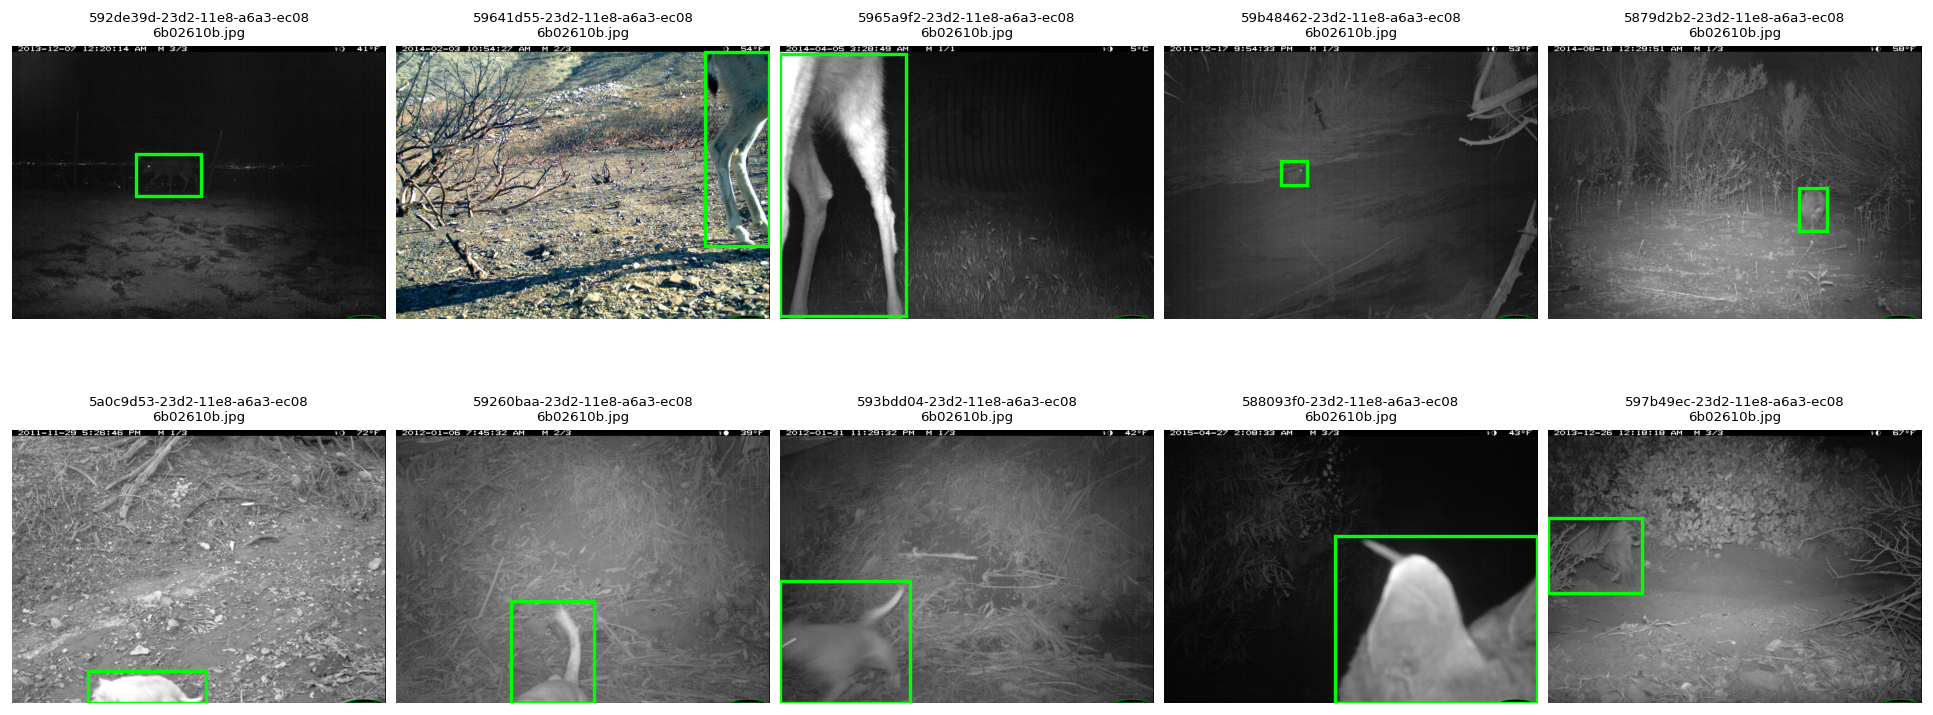

In [56]:
# Publication-style grid for a specific set of images with MD bounding boxes

from pathlib import Path
import textwrap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

selected_files = [
    "592de39d-23d2-11e8-a6a3-ec086b02610b.jpg",
    "59641d55-23d2-11e8-a6a3-ec086b02610b.jpg",
    "5965a9f2-23d2-11e8-a6a3-ec086b02610b.jpg",
    "59b48462-23d2-11e8-a6a3-ec086b02610b.jpg",
    "5879d2b2-23d2-11e8-a6a3-ec086b02610b.jpg",
    "5a0c9d53-23d2-11e8-a6a3-ec086b02610b.jpg",
    "59260baa-23d2-11e8-a6a3-ec086b02610b.jpg",
    "593bdd04-23d2-11e8-a6a3-ec086b02610b.jpg",
    "588093f0-23d2-11e8-a6a3-ec086b02610b.jpg",
    "597b49ec-23d2-11e8-a6a3-ec086b02610b.jpg",
]

def show_selected_images_grid(
    file_names,
    ncols=5,
    img_size=3.4,
    show_filenames=True,
    save_path=None,
    dpi=300,
):
    """
    Display a neat publication-style grid for a fixed list of images.
    Assumes these already exist from earlier cells:
      - IMAGE_BASE
      - md_lookup
      - dataset_path_to_local_name(...)
      - draw_bbox_on_ax(...)
    """
    n = len(file_names)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * img_size, nrows * img_size),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    for ax, file_name in zip(axes[:n], file_names):
        img_path = Path(IMAGE_BASE) / file_name
        local_name = dataset_path_to_local_name(file_name)
        det = md_lookup.get(local_name)

        try:
            image = Image.open(img_path).convert("RGB")
            ax.imshow(image)

            if det is not None:
                draw_bbox_on_ax(ax, image, det["bbox"])
            else:
                ax.text(
                    0.5, 0.03, "No bbox",
                    ha="center", va="bottom",
                    transform=ax.transAxes,
                    fontsize=8, color="orange",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
                )
        except Exception as e:
            ax.set_facecolor("#eeeeee")
            ax.text(
                0.5, 0.5, f"Load error\n{e}",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=8, color="red"
            )

        if show_filenames:
            ax.set_title(textwrap.fill(file_name, width=28), fontsize=8, pad=6)

        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    plt.show()


# Display the 10 selected images in a clean 2 x 5 grid
show_selected_images_grid(
    selected_files,
    ncols=5,
    img_size=3.2,
    show_filenames=True,
    save_path="plots/selected_images_grid.pdf",   # remove if you do not want to save
    dpi=300
)